# Đánh giá Cross-dataset Celeb-DF v2 — SBI (eval-only, KHÔNG train/fine-tune)

Load checkpoint SBI (EfficientNet-b4) đã train trên FF++ C23 (chỉ dùng video real để train, tự
sinh fake bằng self-blend), chạy zero-shot qua cache Celeb-DF v2.

## 📋 Kaggle Input cần add
1. `celebdf-v2-face-cache`
2. Checkpoint SBI đã train (`sbi_best.pth`)


In [1]:
import os, glob, time, random, json
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

CELEBDF_CACHE_DIR = "/kaggle/input/datasets/thinhphan1506/celebdf-v2-face-cache/celebdf_v2_cache"   # SỬA path đúng
CELEBDF_MANIFEST  = os.path.join(CELEBDF_CACHE_DIR, "manifest_processed.csv")
BEST_PATH = "/kaggle/input/datasets/thinhphan1506/sbi-trained-pth/sbi_v1/sbi_best.pth"   # SỬA đúng checkpoint

assert os.path.isdir(CELEBDF_CACHE_DIR), f"Không tìm thấy: {CELEBDF_CACHE_DIR}"
assert os.path.exists(CELEBDF_MANIFEST), f"Không tìm thấy: {CELEBDF_MANIFEST}"
assert os.path.exists(BEST_PATH), f"Không tìm thấy checkpoint: {BEST_PATH}"

IMG_SIZE = 380
TTA_USED = "hflip"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "/kaggle/working/sbi_celebdf_eval"
os.makedirs(OUT_DIR, exist_ok=True)
print("Device:", DEVICE)


Device: cuda


## 1. Đọc manifest Celeb-DF v2

In [2]:
manifest = pd.read_csv(CELEBDF_MANIFEST)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists", "partial"])].reset_index(drop=True)
test_df = manifest.copy()

# ==================== ÁNH XẠ LẠI ĐƯỜNG DẪN FRAME VỀ CELEBDF_CACHE_DIR ====================
# File manifest_processed.csv lưu out_dir từ máy tiền xử lý (vd: /kaggle/working/celebdf_v2_cache/...)
# Khi chạy notebook đánh giá, dữ liệu nằm trong CELEBDF_CACHE_DIR (/kaggle/input/...)
def resolve_frame_dir(row, cache_dir):
    orig = str(row.out_dir)
    if os.path.isdir(orig) and len(glob.glob(os.path.join(orig, "*.jpg"))) > 0:
        return orig

    sub = "real" if row.label == 0 else f"fake_{row.method}"

    cand1 = os.path.join(cache_dir, str(row.split), sub, str(row.video_id))
    if os.path.isdir(cand1) and len(glob.glob(os.path.join(cand1, "*.jpg"))) > 0:
        return cand1

    cand2 = os.path.join(cache_dir, sub, str(row.video_id))
    if os.path.isdir(cand2) and len(glob.glob(os.path.join(cand2, "*.jpg"))) > 0:
        return cand2

    orig_norm = orig.replace("\\", "/")
    for marker in ["/test/", "/celebdf_v2_cache/"]:
        if marker in orig_norm:
            rel = orig_norm.split(marker, 1)[1]
            cand = os.path.join(cache_dir, marker.strip("/"), rel)
            if os.path.isdir(cand) and len(glob.glob(os.path.join(cand, "*.jpg"))) > 0:
                return cand
            cand_direct = os.path.join(cache_dir, rel)
            if os.path.isdir(cand_direct) and len(glob.glob(os.path.join(cand_direct, "*.jpg"))) > 0:
                return cand_direct

    cand3 = os.path.join(cache_dir, str(row.video_id))
    if os.path.isdir(cand3) and len(glob.glob(os.path.join(cand3, "*.jpg"))) > 0:
        return cand3

    return cand1

test_df["out_dir"] = [resolve_frame_dir(row, CELEBDF_CACHE_DIR) for row in test_df.itertuples()]

valid_count = sum(1 for d in test_df["out_dir"] if os.path.isdir(d) and len(glob.glob(os.path.join(d, "*.jpg"))) > 0)
print(f"Test videos (Celeb-DF v2): {len(test_df)}")
print(f"Số video tìm thấy ảnh hợp lệ trên đĩa: {valid_count} / {len(test_df)}")

if valid_count == 0:
    print(f"\n⚠️ CẢNH BÁO: Không tìm thấy ảnh nào tại CELEBDF_CACHE_DIR: {CELEBDF_CACHE_DIR}")
    print(f"Ví dụ đường dẫn đang tìm: {test_df['out_dir'].iloc[0] if len(test_df) > 0 else 'N/A'}")
    if os.path.isdir(CELEBDF_CACHE_DIR):
        print("Cấu trúc thực tế bên trong CELEBDF_CACHE_DIR:")
        for item in os.listdir(CELEBDF_CACHE_DIR)[:10]:
            print("  -", item)

assert valid_count > 0, (
    f"Không tìm thấy khung hình nào trong {CELEBDF_CACHE_DIR}! "
    f"Vui lòng kiểm tra lại cấu trúc thư mục của dataset celebdf-v2-face-cache trên Kaggle."
)
print(test_df.groupby(["label", "method"])["video_id"].count())

Test videos (Celeb-DF v2): 518
Số video tìm thấy ảnh hợp lệ trên đĩa: 518 / 518
label  method         
0      original           178
1      Celeb-synthesis    340
Name: video_id, dtype: int64


## 2. Dataset (VideoEvalDataset — copy nguyên xi từ sbi-baseline-training_fixed)

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def to_tensor_norm(img_rgb_uint8):
    img_f = img_rgb_uint8.astype(np.float32) / 255.0
    inp = (img_f - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(inp.transpose(2, 0, 1)).float()


class VideoEvalDataset(Dataset):
    def __init__(self, df):
        self.rows = []
        for row in df.itertuples():
            files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if files: self.rows.append((row.video_id, files, row.label, row.method))
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        vid_id, files, label, method = self.rows[idx]
        imgs = []
        for f in files:
            img = cv2.imread(f)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            imgs.append(to_tensor_norm(img))
        return torch.stack(imgs), label, method, vid_id


test_ds = VideoEvalDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
assert len(test_ds) > 0, f"LỖI: test_ds có 0 video hợp lệ! Kiểm tra lại đường dẫn ảnh trong cache."
print(f"Test videos hợp lệ: {len(test_ds)}")

Test videos hợp lệ: 518


## 3. Kiến trúc EfficientNet-b4 (copy nguyên xi)

In [4]:
!pip install -q timm
import timm

model = timm.create_model("tf_efficientnet_b4", pretrained=False, num_classes=1).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SBI Model (EfficientNet-b4): {n_params/1e6:.1f}M params")


SBI Model (EfficientNet-b4): 17.6M params


## 4. Hàm metric (copy nguyên xi, đồng bộ dự án)

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")   # fake -> bị đoán real (ĐÃ SỬA đúng chuẩn dự án)
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")   # real -> bị đoán fake
    return far, frr, cm

def calc_far_frr_curve(y_true, y_score, n_points=200):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    thresholds = np.linspace(0.0, 1.0, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr, _ = calc_far_frr(y_true, y_score, threshold=t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    if len(y_true) == 0:
        raise ValueError("calc_metrics nhận mảng rỗng (y_true có 0 mẫu). DataLoader hoặc test_ds chưa có dữ liệu!")
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)
    return {"acc": acc, "auc": auc, "eer": eer, "far_at_0.5": far_05, "frr_at_0.5": frr_05,
            "cm_at_0.5": cm_05, "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer,
            "cm_at_eer": cm_eer, "roc_fpr": fpr, "roc_tpr": tpr, "roc_thresholds": roc_thr}
print("OK")

OK


## 5. Load checkpoint + Đánh giá zero-shot (TTA=hflip) + ROC/FAR-FRR/Confusion Matrix

Nạp checkpoint SBI: epoch=13

=== KẾT QUẢ ZERO-SHOT TRÊN CELEB-DF V2 — SBI-EFNB4 (TTA=hflip) ===
Accuracy : 34.56%
AUC      : 59.75%
EER      : 42.70%
FAR@0.5  : 99.12%  |  FRR@0.5 : 1.12%

Confusion Matrix: TN=176 FP=2 FN=337 TP=3


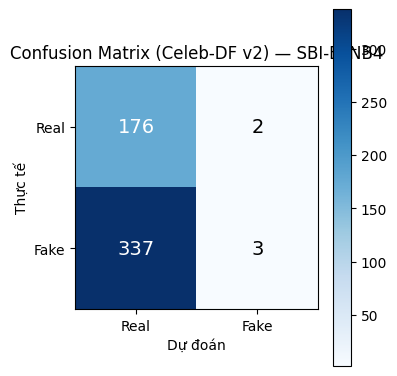

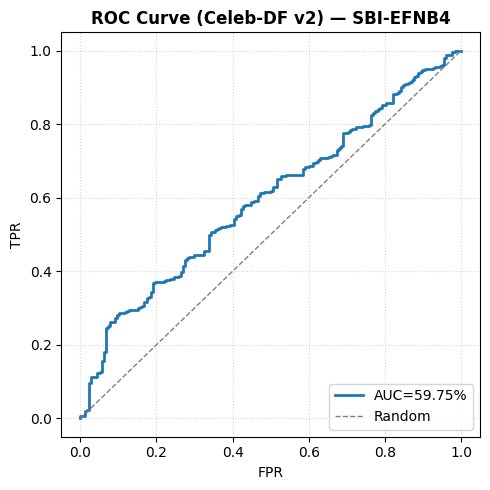

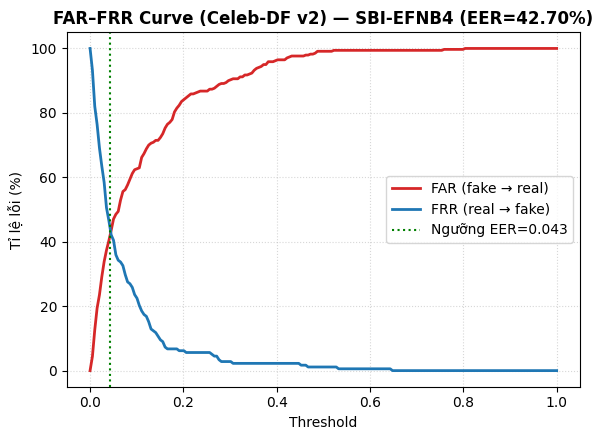


✓ Đã lưu /kaggle/working/sbi_celebdf_eval/test_results_celebdf.csv


In [6]:
MODEL_NAME = "SBI-EFNB4"

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Nạp checkpoint SBI: epoch={ckpt['epoch']}")


@torch.no_grad()
def evaluate_with_tta(model, loader):
    y_true, y_score, methods = [], [], []
    for frames, label, method, _vid in loader:
        frames = frames.squeeze(0).to(DEVICE)
        frames_flip = torch.flip(frames, dims=[3])
        logits_orig = model(frames)
        logits_flip = model(frames_flip)
        prob_orig = torch.sigmoid(logits_orig).mean()
        prob_flip = torch.sigmoid(logits_flip).mean()
        prob = ((prob_orig + prob_flip) / 2).item()
        y_score.append(prob); y_true.append(label.item()); methods.append(method[0])
    return np.array(y_true), np.array(y_score), np.array(methods)


y_true, y_score, methods = evaluate_with_tta(model, test_loader)
assert len(y_true) > 0, "LỖI: evaluate_with_tta không thu được kết quả nào (loader rỗng)!"
test_metrics = calc_metrics(y_true, y_score)

print(f"\n=== KẾT QUẢ ZERO-SHOT TRÊN CELEB-DF V2 — {MODEL_NAME} (TTA={TTA_USED}) ===")
print(f"Accuracy : {test_metrics['acc']*100:.2f}%")
print(f"AUC      : {test_metrics['auc']*100:.2f}%")
print(f"EER      : {test_metrics['eer']*100:.2f}%")
print(f"FAR@0.5  : {test_metrics['far_at_0.5']*100:.2f}%  |  FRR@0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")

cm = test_metrics["cm_at_0.5"]
print(f"\nConfusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title(f"Confusion Matrix (Celeb-DF v2) — {MODEL_NAME}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_celebdf.png"), dpi=100); plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2, color="#1f77b4", label=f"AUC={test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"ROC Curve (Celeb-DF v2) — {MODEL_NAME}", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "roc_curve_celebdf.png"), dpi=150); plt.show()

thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thr, fars * 100, lw=2, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", label=f"Ngưỡng EER={test_metrics['eer_threshold']:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Tỉ lệ lỗi (%)")
ax.set_title(f"FAR–FRR Curve (Celeb-DF v2) — {MODEL_NAME} (EER={test_metrics['eer']*100:.2f}%)", fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "far_frr_curve_celebdf.png"), dpi=150); plt.show()

result_row = {
    "model": MODEL_NAME, "dataset": "CelebDF-v2", "tta_used": TTA_USED,
    "n_real": int((methods == "original").sum()), "n_fake": int((methods == "Celeb-synthesis").sum()),
    "acc": test_metrics["acc"], "auc": test_metrics["auc"], "eer": test_metrics["eer"],
    "far_at_0.5": test_metrics["far_at_0.5"], "frr_at_0.5": test_metrics["frr_at_0.5"],
    "tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1]),
    "notes": "zero-shot, checkpoint train trên FF++ C23 (chỉ real+self-blend), không fine-tune trên Celeb-DF",
}
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_celebdf.csv"), index=False)
print(f"\n✓ Đã lưu {OUT_DIR}/test_results_celebdf.csv")